# ✅ Simple RNN Sentiment Analysis Pipeline using Integers-Enconding
1. Load text dataset (IMDB movie review dataset is built into Keras)
2. Tokenize and pad sequences
3. Build an RNN model (SimpleRNN / LSTM / GRU)
4. Train the model
5. Evaluate and make predictions

# Import Libraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, Dropout, Input, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load Dataset

In [33]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000, skip_top=0)

In [34]:
# keep only 2000 training samples
X_train = X_train[:2000]
y_train = y_train[:2000]

# keep only 500 test samples
X_test = X_test[:500]
y_test = y_test[:500]

# Check Length of Each Sentense

In [35]:
X_train.shape, X_test.shape

((2000,), (500,))

In [36]:
print(f'1st review: {len(X_train[0])}')
print(f'2nd review: {len(X_train[1])}')
print(f'100th review: {len(X_train[99])}')
print(f'200th review: {len(X_train[199])}')

1st review: 218
2nd review: 189
100th review: 171
200th review: 180


# Padding

Hence, the every input is not same

In [37]:
X_train = pad_sequences(sequences=X_train, padding='post', maxlen=50)
X_test = pad_sequences(sequences=X_test, padding='post', maxlen=50)

print(f'1st review: {len(X_train[0])}')
print(f'2nd review: {len(X_train[1])}')
X_train.shape, X_test.shape

1st review: 50
2nd review: 50


((2000, 50), (500, 50))

In [38]:
X_train[0]

array([2071,   56,   26,  141,    6,  194, 7486,   18,    4,  226,   22,
         21,  134,  476,   26,  480,    5,  144,   30, 5535,   18,   51,
         36,   28,  224,   92,   25,  104,    4,  226,   65,   16,   38,
       1334,   88,   12,   16,  283,    5,   16, 4472,  113,  103,   32,
         15,   16, 5345,   19,  178,   32], dtype=int32)

In [39]:
X_train[199]

array([2049,    2, 1091,    5,    2, 2899,    4,    2,    2,    2,   47,
         27,  205, 1419,    2,   18,   57,  282,    5,   47,  684,   77,
       1266,  375,    8, 4425,  968,   11,   35, 2213,    2, 6105,   18,
       7137,   40,   14, 2152, 6343,   10,   10,   14,   20,    9, 1896,
          5,   80, 1487,   25,   67,   12], dtype=int32)

# Simple RNN Model

## Model Build

In [40]:
model = Sequential()

# Input
model.add(Input(shape=(50, 1)))

# RNN Layer
model.add(SimpleRNN(units=32, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())

# Dense Layer
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())

# Output Layer
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,825 (22.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 256 (1.00 KB)

## Model Compile

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [42]:
history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

## Model Predict

In [43]:
test = np.array([2071,   56,   26,  141,    6,  194, 7486,   18,    4,  226,   22,
         21,  134,  476,   26,  480,    5,  144,   30, 5535,   18,   51,
         36,   28,  224,   92,   25,  104,    4,  226,   65,   16,   38,
       1334,   88,   12,   16,  283,    5,   16, 4472,  113,  103,   32,
         15,   16, 5345,   19,  178,   32])
model.predict(test.reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


array([[0.49961072]], dtype=float32)

## Plot Accurcy

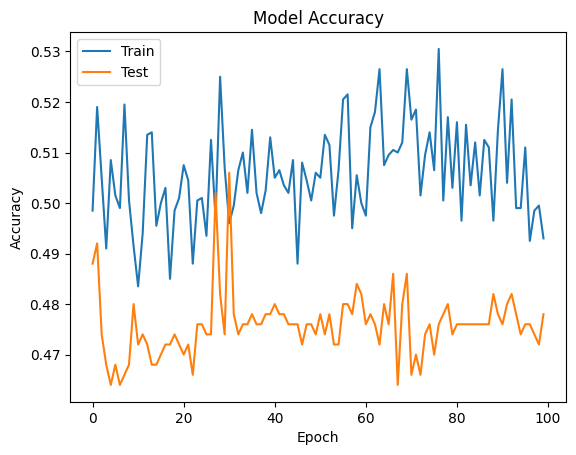

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Loss Plot

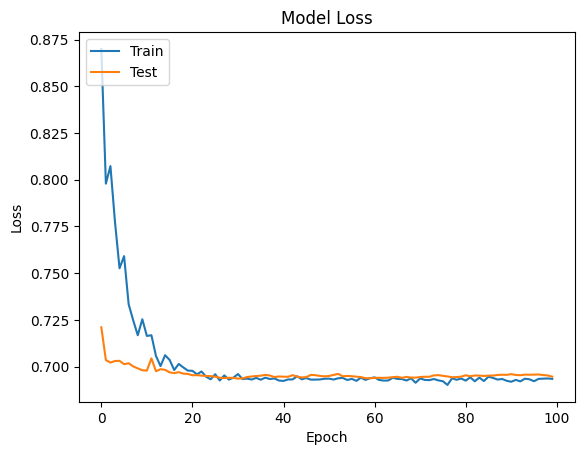

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [46]:
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Final Training Loss: 0.6934
Final Training Accuracy: 0.4930
Final Validation Loss: 0.6946
Final Validation Accuracy: 0.4780


# Embadding RNN Model

## Build Model

In [47]:
model2 = Sequential()

# Input
model2.add(Input(shape=(50,))) # Corrected: Removed the extra dimension

# Embadding Layer
model2.add(Embedding(input_dim=10000, output_dim=3))

# RNN Layer
model2.add(SimpleRNN(units=32, activation='relu'))
model2.add(Dropout(0.5))
model2.add(BatchNormalization())

# Dense Layer
model2.add(Dense(units=64, activation='relu'))
model2.add(Dropout(0.5))
model2.add(BatchNormalization())

model2.add(Dense(units=32, activation='relu'))
model2.add(Dropout(0.5))
model2.add(BatchNormalization())

# Output Layer
model2.add(Dense(units=1, activation='sigmoid'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 3)          │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,889 (140.19 KB)

 Trainable params: 35,633 (139.19 KB)

 Non-trainable params: 256 (1.00 KB)

## Model Compile

In [48]:
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [49]:
history2 = model2.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

## Accuracy Plot

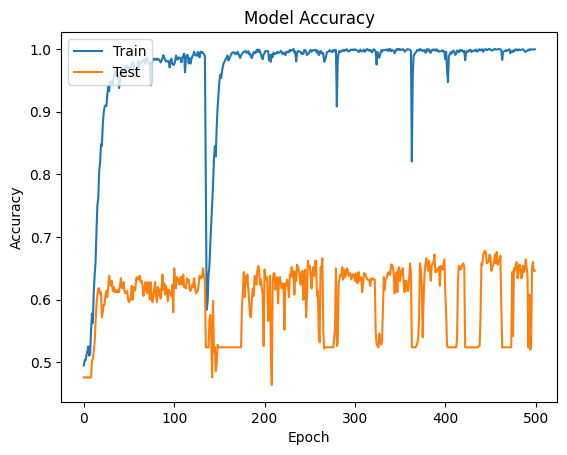

In [50]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Loss Plot

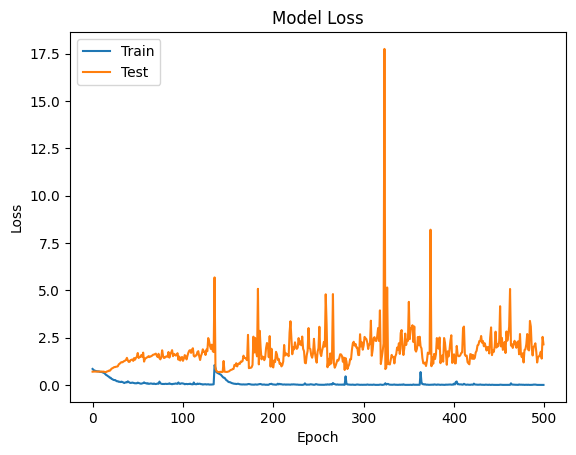

In [51]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [52]:
print(f"Final Training Loss: {history2.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history2.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history2.history['val_accuracy'][-1]:.4f}")

Final Training Loss: 0.0023
Final Training Accuracy: 0.9995
Final Validation Loss: 2.1448
Final Validation Accuracy: 0.6460
